# Feature Engineering — Origination-Time PD Scorecard

**Objective.** Build a leakage-free feature set to estimate a loan's *probability of default (PD)* using only information known **at origination** — an application scorecard, the standard first-line credit model.

**Design choices (and why):**
- **Target = Basel default.** A loan is *bad* if it ever reaches **90+ days past due** (delinquency status ≥ 3) **or** terminates in a **credit event** (zero-balance code 02 third-party sale, 03 short sale/charge-off, 09 REO). Terminal-only labels miss loans that go seriously delinquent but are censored/cured; code 15 (whole-loan sale) is a portfolio action, not a default.
- **Origination-time features only.** The monthly performance file is used *once*, to build the label. Its loss/recovery/delinquency columns are realised *after* default → using them as predictors is target leakage.
- **WOE + IV encoding.** Weight-of-Evidence + Information Value is the industry-standard scorecard method: monotone, interpretable, and it maps directly to points. We deliberately avoid PCA — a PD model must produce reason codes, and principal components are uninterpretable.
- **Out-of-time split by vintage.** Train 2000–2006, validate on 2007 (crisis peak), test 2008–2010. This mimics how a model is actually deployed: fit on the past, judged on unseen future vintages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

ORIG_PATH = "master_origination_clean.parquet"
PERF_PATH = "master_monthly_performance_clean.parquet"
RANDOM_STATE = 42

## 1. Target construction — Basel default at loan level

We scan the performance panel once and flag any loan that ever hit 90+ DPD or a credit-event zero-balance code. This is a single loan-level label, joined back to origination.

In [2]:
perf = pd.read_parquet(
    PERF_PATH,
    columns=["loan_seq_no", "current_loan_delinquency_status", "zero_balance_code"],
)

# delinquency status is a count of months past due; "RA" (relief) and blanks -> NaN
dpd = pd.to_numeric(perf["current_loan_delinquency_status"], errors="coerce")

CREDIT_EVENT_CODES = [2, 3, 9]          # third-party sale, short sale/charge-off, REO
perf["bad"] = dpd.ge(3) | perf["zero_balance_code"].isin(CREDIT_EVENT_CODES)

# loan is bad if it was ever bad over its observed life
label = perf.groupby("loan_seq_no")["bad"].max().astype(int).rename("default")
del perf, dpd

print(f"Loans with a performance record: {label.shape[0]:,}")
print(f"Overall default rate: {label.mean()*100:.2f}%")

Loans with a performance record: 550,000
Overall default rate: 7.19%


In [3]:
og = pd.read_parquet(ORIG_PATH)
og = og.merge(label, left_on="loan_seq_no", right_index=True, how="left")
og["default"] = og["default"].fillna(0).astype(int)   # no perf record -> never went bad
print("Origination rows:", len(og), "| columns:", og.shape[1])

Origination rows: 550000 | columns: 34


Default rate by vintage tells the crisis story cleanly — a monotone climb into the 2007 vintage, then a sharp fall as post-crisis underwriting tightened. This is exactly why we split out-of-time.

                      n  defaults  default_rate_%
origination_year                                 
2000              50000      1750            3.50
2001              50000      1617            3.23
2002              50000      1697            3.39
2003              50000      2033            4.07
2004              50000      3555            7.11
2005              50000      5514           11.03
2006              50000      7212           14.42
2007              50000      8258           16.52
2008              50000      4660            9.32
2009              50000      1599            3.20
2010              50000      1625            3.25


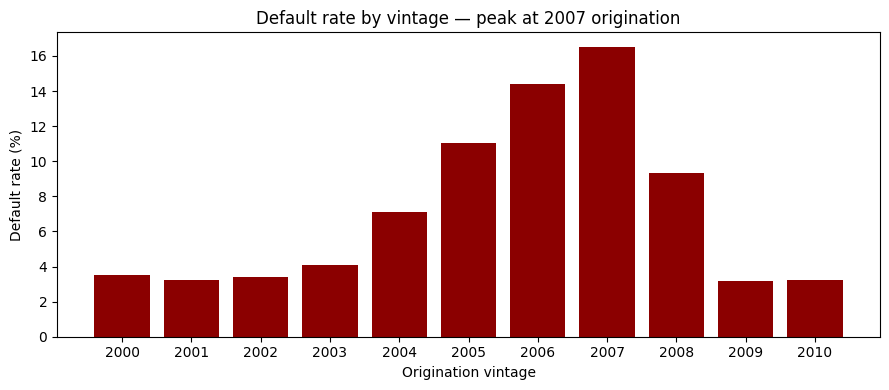

In [4]:
vintage = og.groupby("origination_year")["default"].agg(n="count", defaults="sum")
vintage["default_rate_%"] = (vintage["defaults"] / vintage["n"] * 100).round(2)
print(vintage.to_string())

plt.figure(figsize=(9, 4))
plt.bar(vintage.index.astype(str), vintage["default_rate_%"], color="#8B0000")
plt.ylabel("Default rate (%)"); plt.xlabel("Origination vintage")
plt.title("Default rate by vintage — peak at 2007 origination")
plt.tight_layout(); plt.show()

## 2. Out-of-time split

We split **before any fitting**. All statistics (medians, WOE tables, quantile bin edges) are learned on **train only** and applied to val/test — this is what keeps the pipeline leakage-free.

Note the label drift is real and economic, not a bug: 2007 (validation) is the worst vintage, 2008–10 (test) recover as credit boxes tightened. Validating on the hardest year is a conservative choice.

In [5]:
train_df = og[og["origination_year"].between(2000, 2006)].copy()
val_df   = og[og["origination_year"] == 2007].copy()
test_df  = og[og["origination_year"].between(2008, 2010)].copy()

for name, d in [("train 00-06", train_df), ("val 2007", val_df), ("test 08-10", test_df)]:
    print(f"{name:12} n={len(d):>7,}  default_rate={d['default'].mean()*100:5.2f}%")

train 00-06  n=350,000  default_rate= 6.68%
val 2007     n= 50,000  default_rate=16.52%
test 08-10   n=150,000  default_rate= 5.26%


## 3. Sentinel cleaning

Freddie Mac encodes "missing/unknown" with out-of-range sentinels (9999 FICO, 999 for DTI/LTV/CLTV/MI, 99 for units/borrowers, '9'/'99' for some categoricals). We map these to `NaN` so they are handled explicitly rather than treated as extreme numeric values.

In [6]:
NUM_VALID = {
    "cred_score": (300, 850),
    "og_dti":     (1, 65),
    "og_ltv":     (6, 105),
    "og_cltv":    (6, 200),
    "no_of_borrowers": (1, 10),
    "unit_no":    (1, 4),
}
# mortgage_insurance_percent: 0 = "no MI" is valid; only 999/out-of-range is missing
for d in (train_df, val_df, test_df):
    for col, (lo, hi) in NUM_VALID.items():
        d[col] = d[col].where(d[col].between(lo, hi), np.nan)
    d["mortgage_insurance_percent"] = d["mortgage_insurance_percent"].where(
        (d["mortgage_insurance_percent"] == 0) | d["mortgage_insurance_percent"].between(1, 55),
        np.nan,
    )

CAT_MISSING = {"first_time_homebuyer_flag": "9", "channel": "9", "prop_type": "99"}
for d in (train_df, val_df, test_df):
    for col, sentinel in CAT_MISSING.items():
        d[col] = d[col].replace(sentinel, np.nan)

print("Sentinels -> NaN done. Train NaN counts (key cols):")
print(train_df[list(NUM_VALID) + ["mortgage_insurance_percent"]].isna().sum())

Sentinels -> NaN done. Train NaN counts (key cols):
cred_score                    1517
og_dti                        7724
og_ltv                          26
og_cltv                         27
no_of_borrowers                111
unit_no                          9
mortgage_insurance_percent       9
dtype: int64


## 4. Missing values — informative-missingness flags + train-median imputation

Two columns carry *informative* missingness (the fact of being missing predicts default), so we keep a binary flag before imputing:
- **MSA** — 31.6% missing, and missing-MSA loans default at a different rate.
- **DTI** — the 999 sentinel is not missing-at-random (often thin-file / non-standard underwriting).

Everything else is median-imputed with the **train** median.

In [7]:
# informative-missingness indicators (built from the raw sentinel state)
for d in (train_df, val_df, test_df):
    d["msa_missing"] = (d["metro_code_msa"].astype(str) == "Unknown").astype(int)
    d["dti_missing"] = d["og_dti"].isna().astype(int)

# quick check the MSA flag actually separates risk (train)
print(pd.crosstab(train_df["msa_missing"], train_df["default"], normalize="index").round(3))

IMPUTE_COLS = ["cred_score", "og_dti", "og_ltv", "og_cltv",
               "mortgage_insurance_percent", "no_of_borrowers", "unit_no"]
train_medians = train_df[IMPUTE_COLS].median()
for d in (train_df, val_df, test_df):
    d[IMPUTE_COLS] = d[IMPUTE_COLS].fillna(train_medians)

print("\nTrain medians used for imputation:")
print(train_medians)

default          0      1
msa_missing              
0            0.917  0.083
1            0.960  0.040



Train medians used for imputation:
cred_score                    731.0
og_dti                         33.0
og_ltv                         75.0
og_cltv                        75.0
mortgage_insurance_percent      0.0
no_of_borrowers                 2.0
unit_no                         1.0
dtype: float64


## 5. Feature construction (origination-time, economically grounded)

All derived from origination fields, so no leakage. Each has a credit rationale:

| Feature | Rationale |
|---|---|
| `second_lien_burden` = CLTV − LTV | piggyback / subordinate debt; borrower has less real equity than LTV suggests |
| `rate_spread_vintage` = rate − vintage-median rate | risk-based pricing / adverse selection: paying above the vintage market rate signals a weaker borrower |
| `est_monthly_pi` (annuity formula) | the actual dollar payment obligation combining size, rate, term |
| `high_ltv_flag` (LTV > 80) | conventional cutoff where MI is required; thin equity buffer |
| `has_mi_flag`, `is_cashout`, `is_purchase`, `single_borrower`, `term_years` | standard underwriting cuts |

We keep **LTV** (first-lien leverage, the primary underwriting metric) and the incremental **second_lien_burden**, and drop CLTV — this removes the LTV/CLTV collinearity (r≈0.97) while retaining the second-lien signal.

In [8]:
# vintage-median rate learned on TRAIN only, applied to all splits
vintage_rate = train_df.groupby("origination_year")["og_int_rate"].median()
global_rate  = train_df["og_int_rate"].median()

def add_features(d):
    d = d.copy()
    d["second_lien_burden"] = (d["og_cltv"] - d["og_ltv"]).clip(lower=0)
    d["rate_spread_vintage"] = d["og_int_rate"] - d["origination_year"].map(vintage_rate).fillna(global_rate)

    r = d["og_int_rate"] / 100 / 12
    n = d["og_loan_term"].clip(lower=1)
    d["est_monthly_pi"] = d["og_upb"] * r / (1 - (1 + r) ** (-n))

    d["high_ltv_flag"]  = (d["og_ltv"] > 80).astype(int)
    d["has_mi_flag"]    = (d["mortgage_insurance_percent"] > 0).astype(int)
    d["is_cashout"]     = (d["loan_purpose"] == "C").astype(int)
    d["is_purchase"]    = (d["loan_purpose"] == "P").astype(int)
    d["single_borrower"] = (d["no_of_borrowers"] == 1).astype(int)
    d["term_years"]     = (d["og_loan_term"] / 12).round().astype(int)
    return d

train_df = add_features(train_df)
val_df   = add_features(val_df)
test_df  = add_features(test_df)
print("Engineered features added.")
print(train_df[["second_lien_burden", "rate_spread_vintage", "est_monthly_pi"]].describe().round(2))

Engineered features added.
       second_lien_burden  rate_spread_vintage  est_monthly_pi
count           350000.00            350000.00       350000.00
mean                 1.19                 0.00         1027.54
std                  4.43                 0.49          512.02
min                  0.00                -4.25           53.96
25%                  0.00                -0.25          638.06
50%                  0.00                 0.00          928.71
75%                  0.00                 0.25         1323.79
max                100.00                 3.82         5430.12


## 6. WOE + IV framework

**Weight of Evidence** for a bin: `WOE = ln(%good / %bad)`, where good = non-default. **Information Value** for a variable: `IV = Σ (%good − %bad) · WOE`.

Rules of thumb for IV: <0.02 useless · 0.02–0.1 weak · 0.1–0.3 medium · 0.3–0.5 strong · >0.5 very strong (check for leakage).

Numeric variables are **coarse-binned** (domain bands where sensible, quantiles otherwise); categoricals bin on their own levels. Everything is fit on **train** and applied with a **global-WOE fallback** for unseen bins.

In [9]:
def woe_table(df, feature_binned, target="default"):
    g = df.groupby(feature_binned, observed=True)[target].agg(total="count", bad="sum")
    g["good"] = g["total"] - g["bad"]
    tot_good, tot_bad = g["good"].sum(), g["bad"].sum()
    g["dist_good"] = g["good"] / tot_good
    g["dist_bad"]  = g["bad"]  / tot_bad
    eps = 1e-6
    g["woe"] = np.log((g["dist_good"] + eps) / (g["dist_bad"] + eps))
    g["iv_contrib"] = (g["dist_good"] - g["dist_bad"]) * g["woe"]
    iv = g["iv_contrib"].sum()
    global_woe = np.log((tot_good / (tot_good + tot_bad)) / (tot_bad / (tot_good + tot_bad)) + eps)
    return g, iv, global_woe

# fixed numeric bin edges (domain bands for the classic underwriting variables,
# train quantiles for the rest). Edges are frozen from train and reused on val/test.
def q_edges(s, n=5):
    e = np.unique(np.quantile(s.dropna(), np.linspace(0, 1, n + 1)))
    e[0], e[-1] = -np.inf, np.inf
    return e

NUM_BINS = {
    "cred_score":   [-np.inf, 620, 660, 700, 740, 780, np.inf],
    "og_ltv":       [-np.inf, 60, 70, 80, 90, 97, np.inf],
    "og_dti":       [-np.inf, 20, 30, 36, 43, 50, np.inf],
    "og_int_rate":  q_edges(train_df["og_int_rate"]),
    "og_upb":       q_edges(train_df["og_upb"]),
    "mortgage_insurance_percent": [-np.inf, 0, 12, 25, 30, np.inf],
    "second_lien_burden":  [-np.inf, 0, 5, 20, np.inf],
    "rate_spread_vintage": q_edges(train_df["rate_spread_vintage"]),
    "est_monthly_pi":      q_edges(train_df["est_monthly_pi"]),
}
CAT_VARS = ["loan_purpose", "occupancy_status", "channel", "prop_type",
            "first_time_homebuyer_flag", "prop_state", "seller_name", "servicer_name"]
BINARY_VARS = ["msa_missing", "dti_missing", "high_ltv_flag", "has_mi_flag",
               "is_cashout", "is_purchase", "single_borrower"]
print("Framework ready.")

Framework ready.


Compute the WOE map + IV for every candidate variable on train, and rank by IV. This single table is the feature-selection backbone of the scorecard.

In [10]:
woe_maps = {}     # feature -> (mapping dict, global_woe, kind, edges)
iv_rows = []

def binned_series(s, edges):
    return pd.cut(s, edges, include_lowest=True)

# numeric
for feat, edges in NUM_BINS.items():
    b = binned_series(train_df[feat], edges)
    tbl, iv, gwoe = woe_table(train_df.assign(_b=b), "_b")
    woe_maps[feat] = (tbl["woe"].to_dict(), gwoe, "num", edges)
    iv_rows.append((feat, iv, "numeric"))

# categorical
for feat in CAT_VARS:
    tbl, iv, gwoe = woe_table(train_df.assign(_b=train_df[feat].astype(str)), "_b")
    woe_maps[feat] = (tbl["woe"].to_dict(), gwoe, "cat", None)
    iv_rows.append((feat, iv, "categorical"))

# binary flags (treated as 2-level categoricals)
for feat in BINARY_VARS:
    tbl, iv, gwoe = woe_table(train_df.assign(_b=train_df[feat].astype(str)), "_b")
    woe_maps[feat] = (tbl["woe"].to_dict(), gwoe, "cat", None)
    iv_rows.append((feat, iv, "binary"))

iv_df = pd.DataFrame(iv_rows, columns=["feature", "IV", "type"]).sort_values("IV", ascending=False).reset_index(drop=True)
def strength(v):
    return ("useless" if v < 0.02 else "weak" if v < 0.1 else "medium" if v < 0.3 else "strong" if v < 0.5 else "very strong")
iv_df["strength"] = iv_df["IV"].apply(strength)
print(iv_df.to_string(index=False))

                   feature           IV        type    strength
                cred_score 6.154735e-01     numeric very strong
             servicer_name 5.963746e-01 categorical very strong
               seller_name 2.689381e-01 categorical      medium
                    og_ltv 2.213172e-01     numeric      medium
                    og_dti 1.573077e-01     numeric      medium
       rate_spread_vintage 1.554939e-01     numeric      medium
           single_borrower 1.391879e-01      binary      medium
               msa_missing 1.232158e-01      binary      medium
                prop_state 1.152417e-01 categorical      medium
mortgage_insurance_percent 1.062855e-01     numeric      medium
             high_ltv_flag 1.009370e-01      binary      medium
               has_mi_flag 9.841103e-02      binary        weak
               og_int_rate 8.703521e-02     numeric        weak
              loan_purpose 5.052864e-02 categorical        weak
                is_cashout 4.381341e-02 

/tmp/ipykernel_618/1503744371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iv_df, y="feature", x="IV", palette="viridis")


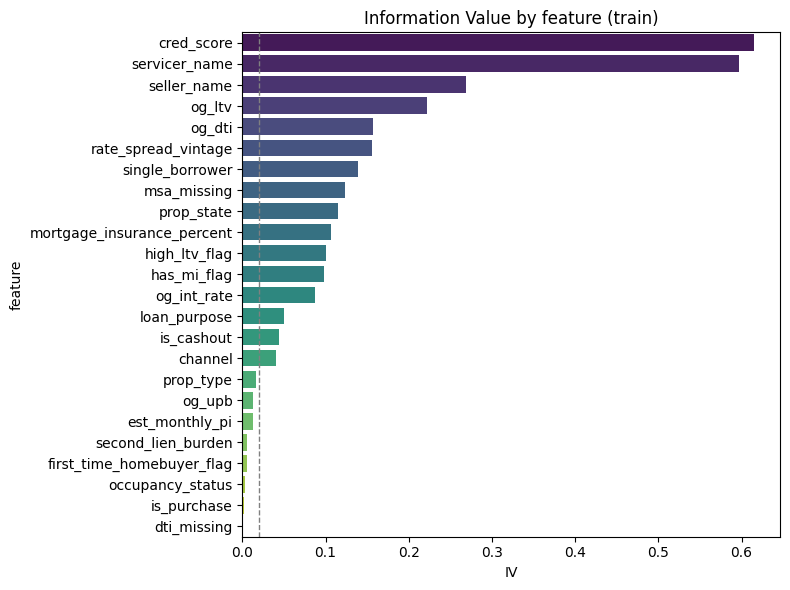

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(data=iv_df, y="feature", x="IV", palette="viridis")
plt.axvline(0.02, color="grey", ls="--", lw=1)
plt.title("Information Value by feature (train)")
plt.tight_layout(); plt.show()

## 7. Feature selection

Two cuts:

1. **Leakage exclusion.** `servicer_name` shows IV ≈ 0.60 — almost as predictive as FICO. That is a warning sign, not a win: delinquent loans are routinely transferred to *special servicers*, so the servicer value partly reflects an outcome that happens **after** origination. We exclude it. `seller_name` is safe — the seller is fixed at origination.
2. **IV floor.** Drop variables with **IV < 0.02** (no discriminatory power). Note the engineered `est_monthly_pi`, `og_upb`, and `second_lien_burden` land here: once LTV and DTI are in, absolute loan *size* adds little — it is the ratios that carry the risk. The IV filter reports that honestly.

Multicollinearity among survivors is handled next via VIF.

In [12]:
LEAKAGE_EXCLUDE = ["servicer_name"]   # post-origination servicing transfers -> outcome leakage

selected = [f for f in iv_df.loc[iv_df["IV"] >= 0.02, "feature"].tolist()
            if f not in LEAKAGE_EXCLUDE]
dropped  = iv_df.loc[iv_df["IV"] <  0.02, "feature"].tolist()
print(f"Excluded for leakage: {LEAKAGE_EXCLUDE}")
print(f"Kept {len(selected)}: {selected}")
print(f"Dropped (IV<0.02): {dropped}")

Excluded for leakage: ['servicer_name']
Kept 15: ['cred_score', 'seller_name', 'og_ltv', 'og_dti', 'rate_spread_vintage', 'single_borrower', 'msa_missing', 'prop_state', 'mortgage_insurance_percent', 'high_ltv_flag', 'has_mi_flag', 'og_int_rate', 'loan_purpose', 'is_cashout', 'channel']
Dropped (IV<0.02): ['prop_type', 'og_upb', 'est_monthly_pi', 'second_lien_burden', 'first_time_homebuyer_flag', 'occupancy_status', 'is_purchase', 'dti_missing']


Apply the train-fitted WOE maps to all three splits. Unseen bins/categories fall back to the global WOE (base-rate log-odds), never to an arbitrary 0.

In [13]:
def apply_woe(df, feature, mapping, gwoe, kind, edges):
    if kind == "num":
        key = binned_series(df[feature], edges)
    else:
        key = df[feature].astype(str)
    return key.map(mapping).astype(float).fillna(gwoe)

def build_woe_matrix(df):
    out = pd.DataFrame(index=df.index)
    for feat in selected:
        mapping, gwoe, kind, edges = woe_maps[feat]
        out[f"{feat}_woe"] = apply_woe(df, feat, mapping, gwoe, kind, edges)
    out["default"] = df["default"].values
    return out

train_woe = build_woe_matrix(train_df)
val_woe   = build_woe_matrix(val_df)
test_woe  = build_woe_matrix(test_df)
print("WOE matrix shapes:", train_woe.shape, val_woe.shape, test_woe.shape)
assert train_woe.isna().sum().sum() == 0
train_woe.head()

WOE matrix shapes: (350000, 16) (50000, 16) (150000, 16)


,cred_score_woe,seller_name_woe,og_ltv_woe,og_dti_woe,rate_spread_vintage_woe,single_borrower_woe,msa_missing_woe,prop_state_woe,mortgage_insurance_percent_woe,high_ltv_flag_woe,has_mi_flag_woe,og_int_rate_woe,loan_purpose_woe,is_cashout_woe,channel_woe,default
0,1.375230,0.222296,-0.598560,0.353158,0.696179,0.345225,0.532251,0.394594,-0.714050,-0.632408,-0.627971,-0.330927,0.061537,0.151772,0.222215,0
1,0.869887,0.222296,0.125070,0.353158,-0.113494,-0.407899,0.532251,0.076917,0.158001,0.160954,0.158001,0.290015,-0.289735,-0.289735,0.222215,0
2,0.869887,0.222296,-0.105449,0.353158,0.696179,0.345225,-0.233892,-0.077356,0.158001,0.160954,0.158001,-0.074191,0.265435,0.151772,0.222215,0
3,0.156648,1.066189,-0.578039,0.017343,0.696179,-0.407899,-0.233892,0.076917,-0.574900,-0.632408,-0.627971,0.290015,0.061537,0.151772,0.222215,0
4,-1.207334,0.222296,-0.105449,0.353158,-0.506980,-0.407899,-0.233892,-0.159223,0.158001,0.160954,0.158001,0.290015,0.265435,0.151772,-0.177257,0


## 8. Multicollinearity check (correlation + VIF)

WOE variables share a common log-odds scale, so correlation and VIF are directly comparable. We prune any feature with **VIF > 5** (drop the higher-VIF, lower-IV member of a collinear pair), which keeps the logistic coefficients stable and signable.

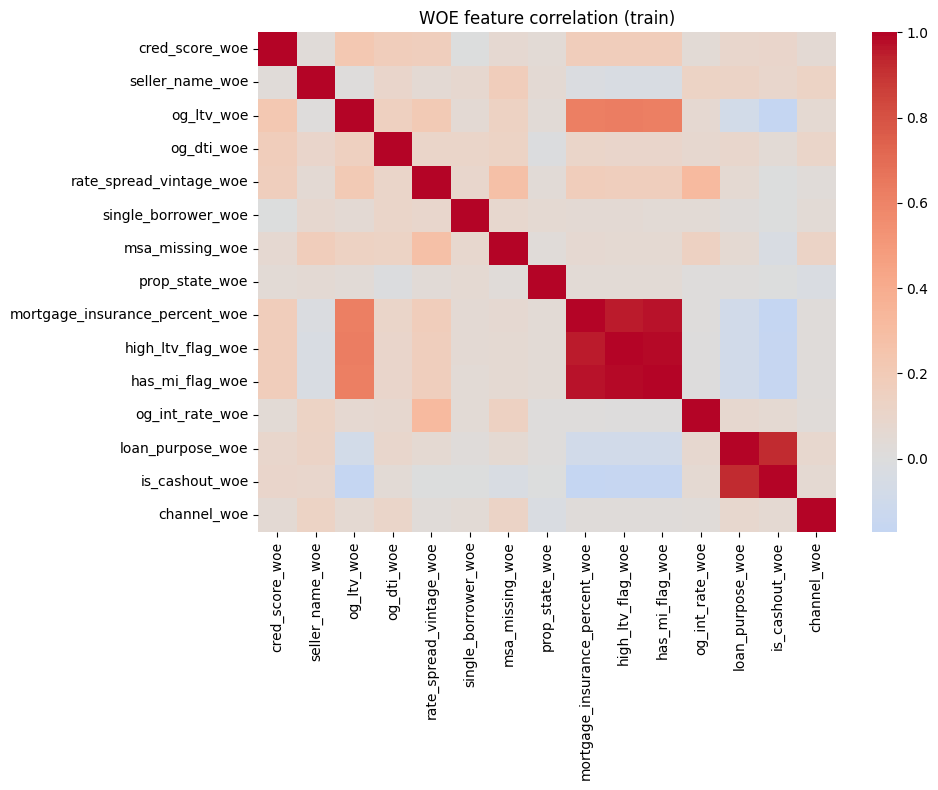

In [14]:
corr = train_woe.drop(columns="default").corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("WOE feature correlation (train)")
plt.tight_layout(); plt.show()

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def vif_table(X):
    Xc = sm.add_constant(X)
    rows = [(c, variance_inflation_factor(Xc.values, i))
            for i, c in enumerate(Xc.columns) if c != "const"]
    return pd.DataFrame(rows, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)

X = train_woe.drop(columns="default")
vif = vif_table(X)
print(vif.to_string(index=False))

# iterative prune: drop highest-VIF feature while any VIF > 5
iv_lookup = dict(zip(iv_df["feature"], iv_df["IV"]))
feat_cols = list(X.columns)
while True:
    v = vif_table(train_woe[feat_cols])
    worst = v.iloc[0]
    if worst["VIF"] <= 5:
        break
    drop_feat = worst["feature"]
    feat_cols.remove(drop_feat)
    print(f"drop {drop_feat} (VIF={worst['VIF']:.1f})")

print("\nFinal features after VIF prune:", feat_cols)

                       feature       VIF
               has_mi_flag_woe 56.688144
             high_ltv_flag_woe 42.370974
mortgage_insurance_percent_woe 16.530431
                is_cashout_woe  8.003590
              loan_purpose_woe  7.788776
                    og_ltv_woe  1.799854
       rate_spread_vintage_woe  1.260845
               msa_missing_woe  1.182015
               og_int_rate_woe  1.140589
                cred_score_woe  1.127977
                    og_dti_woe  1.093204
               seller_name_woe  1.077805
                   channel_woe  1.042984
           single_borrower_woe  1.030734
                prop_state_woe  1.012578


drop has_mi_flag_woe (VIF=56.7)


drop high_ltv_flag_woe (VIF=12.3)


drop is_cashout_woe (VIF=7.9)



Final features after VIF prune: ['cred_score_woe', 'seller_name_woe', 'og_ltv_woe', 'og_dti_woe', 'rate_spread_vintage_woe', 'single_borrower_woe', 'msa_missing_woe', 'prop_state_woe', 'mortgage_insurance_percent_woe', 'og_int_rate_woe', 'loan_purpose_woe', 'channel_woe']


In [16]:
final_cols = feat_cols + ["default"]
train_woe = train_woe[final_cols]
val_woe   = val_woe[final_cols]
test_woe  = test_woe[final_cols]
print("Final VIF:")
print(vif_table(train_woe.drop(columns="default")).to_string(index=False))

Final VIF:


                       feature      VIF
                    og_ltv_woe 1.711318
mortgage_insurance_percent_woe 1.643078
       rate_spread_vintage_woe 1.254570
               msa_missing_woe 1.143135
               og_int_rate_woe 1.137666
                cred_score_woe 1.105531
                    og_dti_woe 1.088837
               seller_name_woe 1.075637
              loan_purpose_woe 1.050877
                   channel_woe 1.042362
           single_borrower_woe 1.030199
                prop_state_woe 1.011934


## 9. Class imbalance

Default rates are ~5–17% across splits — imbalanced but not extreme. Leave the data untouched here and handle it at model time with `class_weight="balanced"` in logistic regression (re-weights the loss, keeps PDs calibratable). We avoid SMOTE: synthesising points in WOE space distorts the very log-odds structure the encoding is built to preserve.

In [17]:
for name, d in [("train", train_woe), ("val", val_woe), ("test", test_woe)]:
    print(f"{name:6} n={len(d):>7,}  defaults={int(d['default'].sum()):>6,}  rate={d['default'].mean()*100:5.2f}%")

train  n=350,000  defaults=23,378  rate= 6.68%
val    n= 50,000  defaults= 8,258  rate=16.52%
test   n=150,000  defaults= 7,884  rate= 5.26%


## 10. Save artifacts

We save the three WOE matrices, the IV table, and the WOE mapping (so the modelling notebook applies the *exact* train-fitted transform to any new data). **No PCA** — the scorecard's value is interpretability, and we hand the modelling notebook clean, named, monotone WOE features ready for logistic regression.

In [18]:
train_woe.to_csv("train_woe.csv", index=False)
val_woe.to_csv("val_woe.csv", index=False)
test_woe.to_csv("test_woe.csv", index=False)
iv_df.to_csv("iv_summary.csv", index=False)

joblib.dump({
    "woe_maps": woe_maps,
    "selected": selected,
    "final_features": [c for c in train_woe.columns if c != "default"],
    "num_bins": NUM_BINS,
    "train_medians": train_medians.to_dict(),
    "vintage_rate": vintage_rate.to_dict(),
    "global_rate": float(global_rate),
    "credit_event_codes": CREDIT_EVENT_CODES,
}, "woe_pipeline.pkl")

print("Saved: train_woe.csv, val_woe.csv, test_woe.csv, iv_summary.csv, woe_pipeline.pkl")
print("Final feature count:", train_woe.shape[1] - 1)

Saved: train_woe.csv, val_woe.csv, test_woe.csv, iv_summary.csv, woe_pipeline.pkl
Final feature count: 12
